In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("../data/raw/train.csv")

# Display First Rows
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [2]:
# Create Date from Week

df['date'] = pd.to_datetime('2018-01-01') + pd.to_timedelta(df['week'] * 7, unit='D')

# Extract Time Features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekofyear'] = df['date'].dt.isocalendar().week
df['dayofweek'] = df['date'].dt.dayofweek

# Weekend Feature
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# Display
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,date,year,month,weekofyear,dayofweek,is_weekend
0,1379560,1,55,1885,136.83,152.29,0,0,177,2018-01-08,2018,1,2,0,0
1,1466964,1,55,1993,136.83,135.83,0,0,270,2018-01-08,2018,1,2,0,0
2,1346989,1,55,2539,134.86,135.86,0,0,189,2018-01-08,2018,1,2,0,0
3,1338232,1,55,2139,339.50,437.53,0,0,54,2018-01-08,2018,1,2,0,0
4,1448490,1,55,2631,243.50,242.50,0,0,40,2018-01-08,2018,1,2,0,0


In [3]:
# Lag Features

df = df.sort_values(by=['meal_id', 'week'])

df['lag_1'] = df.groupby('meal_id')['num_orders'].shift(1)
df['lag_2'] = df.groupby('meal_id')['num_orders'].shift(2)
df['lag_4'] = df.groupby('meal_id')['num_orders'].shift(4)

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,date,year,month,weekofyear,dayofweek,is_weekend,lag_1,lag_2,lag_4
7,1499955,1,55,1062,182.36,183.36,0,0,391,2018-01-08,2018,1,2,0,0,NaN,NaN,NaN
40,1351400,1,24,1062,184.36,182.36,0,0,514,2018-01-08,2018,1,2,0,0,391.0,NaN,NaN
84,1057835,1,11,1062,184.36,182.36,0,0,798,2018-01-08,2018,1,2,0,0,514.0,391.0,NaN
125,1231510,1,83,1062,170.78,170.78,0,0,284,2018-01-08,2018,1,2,0,0,798.0,514.0,NaN
164,1402151,1,32,1062,175.60,174.60,0,0,256,2018-01-08,2018,1,2,0,0,284.0,798.0,391.0


In [4]:
# Rolling Mean Features

df['rolling_mean_3'] = df.groupby('meal_id')['num_orders'] \
                         .transform(lambda x: x.shift(1).rolling(window=3).mean())

df['rolling_mean_5'] = df.groupby('meal_id')['num_orders'] \
                         .transform(lambda x: x.shift(1).rolling(window=5).mean())

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,date,year,month,weekofyear,dayofweek,is_weekend,lag_1,lag_2,lag_4,rolling_mean_3,rolling_mean_5
7,1499955,1,55,1062,182.36,183.36,0,0,391,2018-01-08,2018,1,2,0,0,NaN,NaN,NaN,NaN,NaN
40,1351400,1,24,1062,184.36,182.36,0,0,514,2018-01-08,2018,1,2,0,0,391.0,NaN,NaN,NaN,NaN
84,1057835,1,11,1062,184.36,182.36,0,0,798,2018-01-08,2018,1,2,0,0,514.0,391.0,NaN,NaN,NaN
125,1231510,1,83,1062,170.78,170.78,0,0,284,2018-01-08,2018,1,2,0,0,798.0,514.0,NaN,567.666667,NaN
164,1402151,1,32,1062,175.60,174.60,0,0,256,2018-01-08,2018,1,2,0,0,284.0,798.0,391.0,532.000000,NaN


In [5]:
# Missing Values After Feature Engineering

df.isnull().sum()

id                         0
week                       0
center_id                  0
meal_id                    0
checkout_price             0
base_price                 0
emailer_for_promotion      0
homepage_featured          0
num_orders                 0
date                       0
year                       0
month                      0
weekofyear                 0
dayofweek                  0
is_weekend                 0
lag_1                     51
lag_2                    102
lag_4                    204
rolling_mean_3           153
rolling_mean_5           255
dtype: int64

In [6]:
# Remove Null Values

df.dropna(inplace=True)

print(df.shape)

(456293, 20)


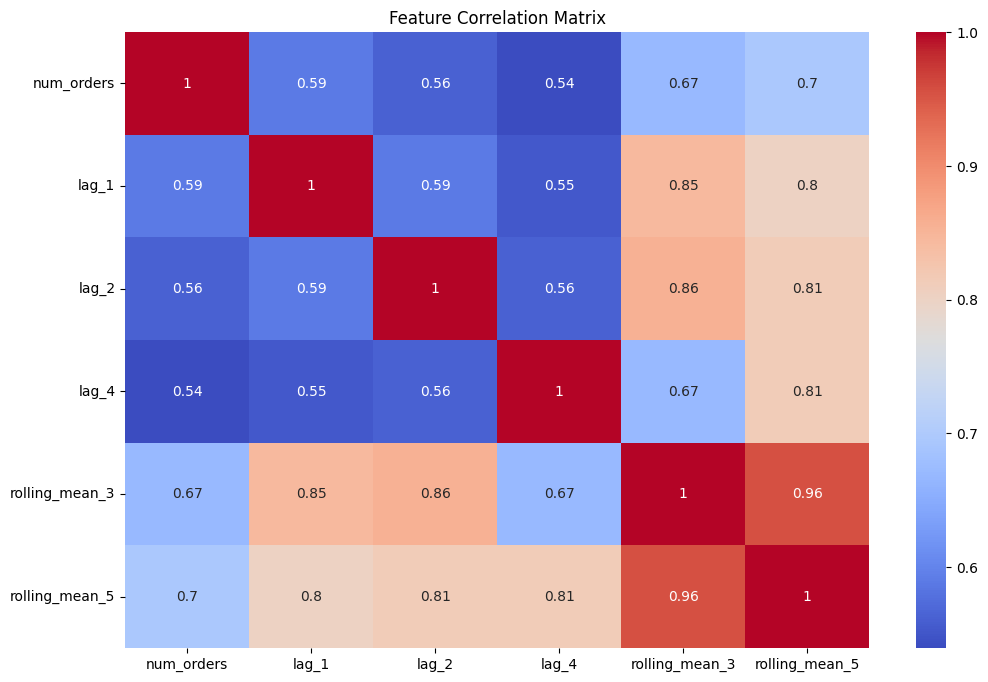

In [7]:
# Correlation Matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    df[['num_orders', 'lag_1', 'lag_2', 'lag_4',
        'rolling_mean_3', 'rolling_mean_5']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [12]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (365034, 20)
Test Shape: (91259, 20)
